In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

ruta = r"C:\Users\javie\OneDrive\Desktop\Excel_DB\clientes.csv"
df = pd.read_csv(ruta)
df.head()

df.drop('direccion', axis=1, inplace=True)
df['edad'] = (df['edad'] // 10) * 10

ruido = np.random.normal(0, 100, size=df['salario'].shape)
df['salario'] += ruido

for i in range(len(df)):
    df.loc[i, 'nombre'] = 'Cliente' + str(i)

print(df.head())

agrupado = df.groupby('categoria')

df_balanceado = pd.DataFrame()

for nombre, grupo in agrupado:
    grupo_balanceado = resample(grupo, 
                                replace=True,
                                n_samples=100,
                                random_state=123)
    df_balanceado = pd.concat([df_balanceado, grupo_balanceado])


     nombre  edad  categoria       salario
0  Cliente0    60          0  60920.516541
1  Cliente1    60          1  53734.113566
2  Cliente2    10          0  60205.539794
3  Cliente3    20          1  42074.392788
4  Cliente4    20          1  37537.459482


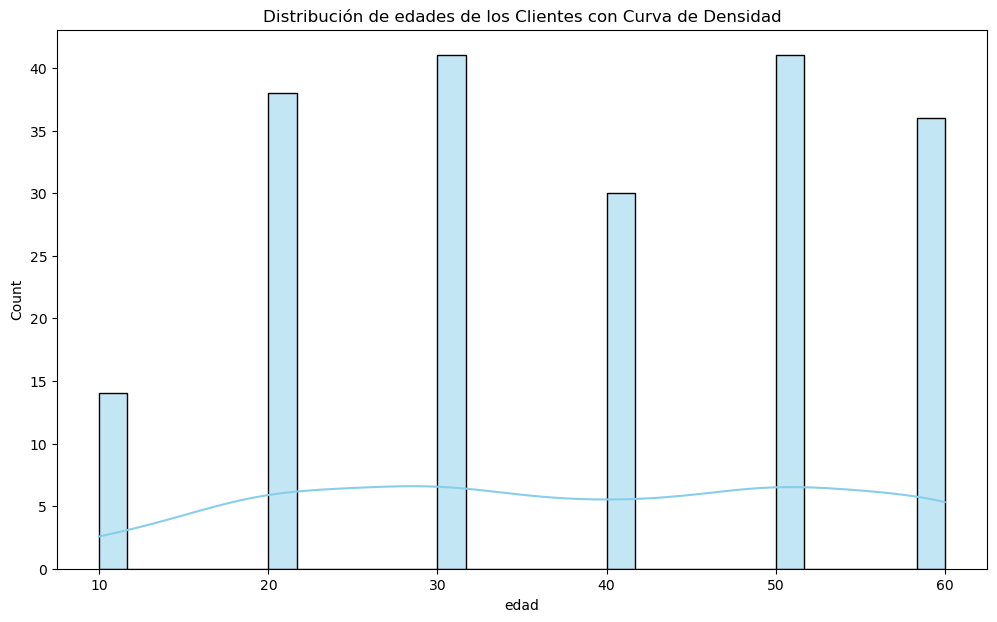

In [4]:
for nombre, grupo in agrupado:
    grupo_balanceado = resample(grupo, 
                                replace=True,
                                n_samples=100,
                                random_state=123)
    df_balanceado = pd.concat([df_balanceado, grupo_balanceado])

plt.figure(figsize=(12, 7))
ax = sns.histplot(df['edad'],
                    kde=True, 
                    color='skyblue',
                    bins=30)
ax.set(title='Distribución de edades de los Clientes con Curva de Densidad'),
xlabel = 'Edad',
ylabel = 'Frecuencia';
plt.show()

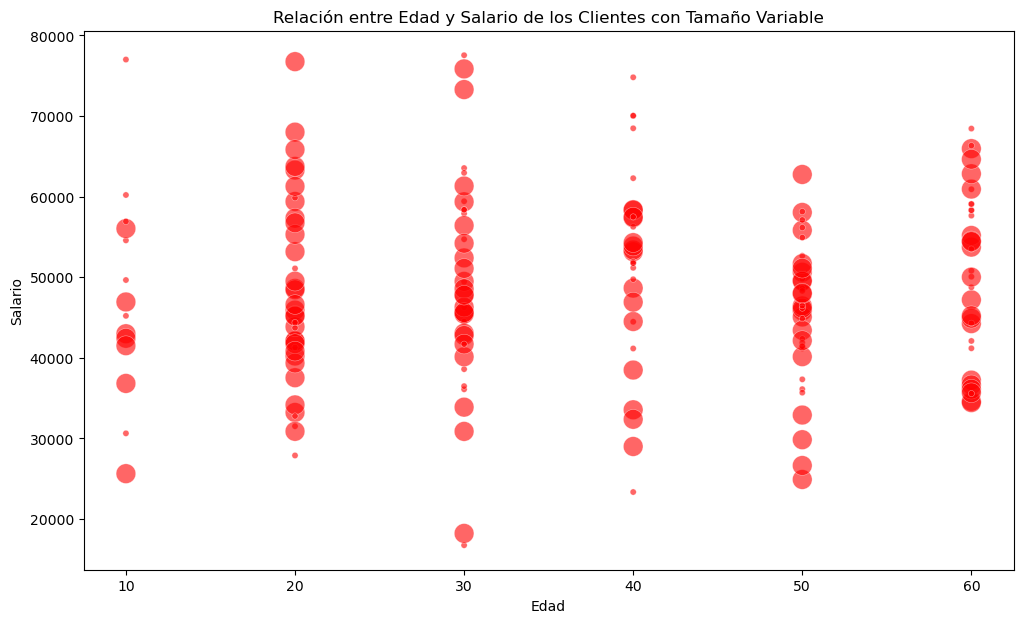

In [5]:

plt.figure(figsize=(12 , 7))
sizes = df['categoria'].replace({0: 50, 1: 100})
scatter = sns.scatterplot(x='edad',
                            y='salario',
                            size=sizes,
                            legend=False,
                            sizes=(20, 200),
                            data=df,
                            color='red',
                            alpha=0.6)
scatter.set(title='Relación entre Edad y Salario de los Clientes con Tamaño Variable',
            xlabel='Edad',
            ylabel='Salario');

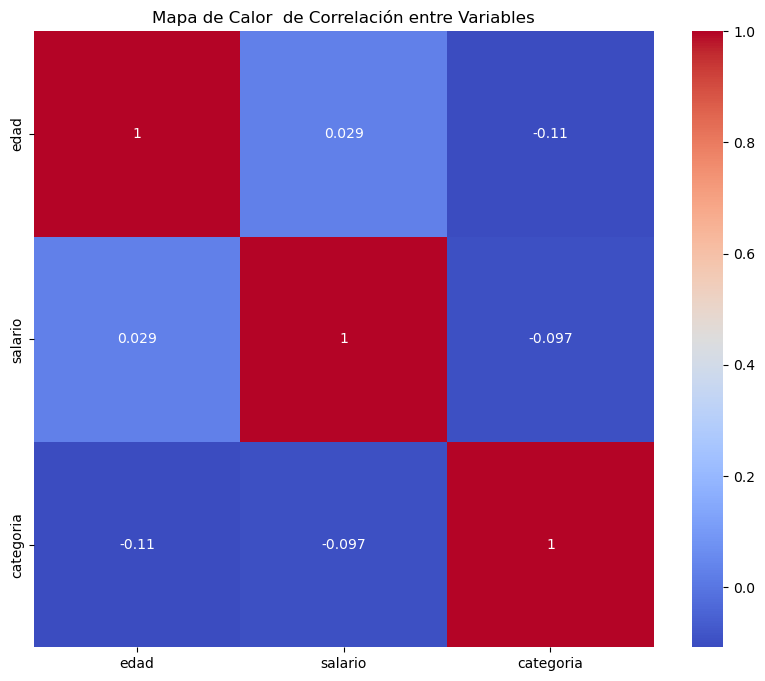

In [6]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[['edad', 'salario', 'categoria']].corr()
heatmap = sns.heatmap(correlation_matrix,
                      annot=True, 
                      cmap='coolwarm')
heatmap.set(title='Mapa de Calor  de Correlación entre Variables');
plt.show()